<a href="https://colab.research.google.com/github/Tejasp9090/ML_Practice/blob/main/ML_Day_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prepare data

marks = [[98],[80],[40],[20],[85],[40],[30]]  # input
result = ['Pass','Pass','Fail','Fail','Pass','Fail','Fail'] # output

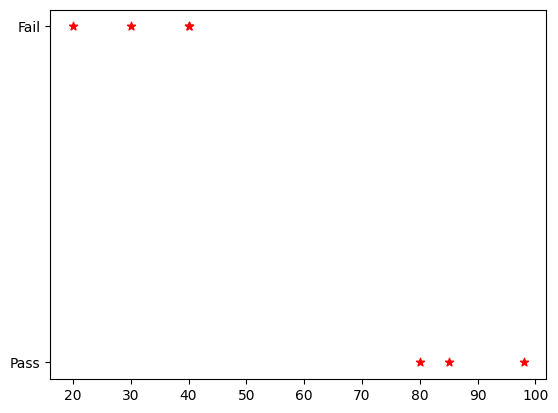

In [2]:
# Analyze The Data

import matplotlib.pyplot as plt
plt.scatter(marks,result,marker='*',color='red')
plt.show()

In [3]:
# Traning ----> Algorithm
from sklearn.linear_model import LogisticRegression

In [4]:
# Lets create an object of algorithm = Initialzing the algorithm
model = LogisticRegression()
model

LogisticRegression()

In [5]:
# Train The Model
model.fit(marks,result)

LogisticRegression()

In [14]:
# Testing
model.predict([[100]])

array(['Pass'], dtype='<U4')

In [16]:
model.predict([[35],[59],[61],[70],[81]])

array(['Fail', 'Fail', 'Pass', 'Pass', 'Pass'], dtype='<U4')

In [17]:
import os
# Install gradio if it is not already installed
try:
    import gradio as gr
except ImportError:
    os.system('pip install -q gradio')
    import gradio as gr

def predict_marks(mark):
    # The model expects a 2D array-like input
    prediction = model.predict([[mark]])[0]
    probabilities = model.predict_proba([[mark]])[0]

    # Map classes to their respective probabilities
    classes = model.classes_
    prob_dict = {classes[i]: float(probabilities[i]) for i in range(len(classes))}

    return prediction, prob_dict

# Set up the Gradio Interface
demo = gr.Interface(
    fn=predict_marks,
    inputs=gr.Number(label="Enter Mark", value=50),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(label="Class Probabilities")
    ],
    title="Student Result Predictor",
    description="Enter a student's marks to predict whether they will Pass or Fail using the trained Logistic Regression model, along with class probabilities."
)

# Launch the interface in the Colab notebook
demo.launch(quiet=True)

* Running on public URL: https://abebb15bc8879893b8.gradio.live
